# Project 2 — Book lengths in characters, words, and tokens

**Chapter 2 · Tokenization** · pp. 28–30

Import 10 out-of-copyright books from Project Gutenberg and compare their lengths in **characters**, **words**, and **GPT-2 tokens** — total and unique.

In [1]:
import numpy as np
import requests
import matplotlib.pyplot as plt

In [2]:
### matplotlib adjustments
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

plt.rcParams.update({
    'axes.spines.right': False,
    'axes.spines.top':   False,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
    'savefig.dpi':300,
})


# **How to import a book from gutenberg.org**

In [3]:
url = "https://www.gutenberg.org/cache/epub/84/pg84.txt"
text = requests.get(url).text
print(text[:1000])

The Project Gutenberg eBook of Frankenstein; or, the modern prometheus
    
This eBook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms
of the Project Gutenberg License included with this eBook or online
at www.gutenberg.org. If you are not located in the United States,
you will have to check the laws of the country where you are located
before using this eBook.

Title: Frankenstein; or, the modern prometheus

Author: Mary Wollstonecraft Shelley


        
Release date: October 1, 1993 [eBook #84]
                Most recently updated: February 10, 2026

Language: English

Other information and formats: www.gutenberg.org/ebooks/84

Credits: Judith Boss, Christy Phillips, Lynn Hanninen and David Meltzer. HTML version by Al Haines.
        Further corrections by Menno de Leeuw.


*** START OF THE PROJECT GUTEN


# **Part 1: Total characters, words, and tokens**

In [4]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("gpt2")

/Users/johnmachado/Desktop/50 ML Projects to Understand LLMs/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# all books have the same url format;
# they are unique by numerical code
baseurl = "https://www.gutenberg.org/cache/epub/"

bookurls = [
    # code       title
    ["84", "Frankenstein"],
    ["64317", "GreatGatsby"],
    ["11", "AliceWonderland"],
    ["1513", "RomeoJuliet"],
    ["76", "HuckFinn"],
    ["219", "HeartDarkness"],
    ["2591", "GrimmsTales"],
    ["2148", "EdgarAllenPoe"],
    ["36", "WarOfTheWorlds"],
    ["829", "GulliversTravels"]
]

In [6]:
print(f"{'Book title':16} | {'Chars':>9} | {'Words':>9} | {'Tokens':>9}")
print(f"{'-'*16}-+-{'-'*9}-+-{'-'*9}-+-{'-'*9}")

for code, title in bookurls:

    # get the text
    fullurl = baseurl + code + "/pg" + code + ".txt"
    text = requests.get(fullurl).text

    characters = [c for c in text]
    words = text.split()
    tokens = tokenizer.encode(text)

    # counts of different token types
    n_chars = len(characters) # number of characters in text
    n_words = len(words)      # number of words (split text on whitespace)
    n_tokens = len(tokens)    # number of GPT-2 tokens (encode text)

    print(f"{title:16} | {n_chars:>9,} | {n_words:>9,} | {n_tokens:>9,}") 

Book title       |     Chars |     Words |    Tokens
-----------------+-----------+-----------+----------


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (114213 > 1024). Running this sequence through the model will result in indexing errors


Frankenstein     |   446,582 |    78,106 |   114,213
GreatGatsby      |   296,899 |    51,262 |    89,263
AliceWonderland  |   167,712 |    29,569 |    52,948
RomeoJuliet      |   167,469 |    29,005 |    56,180
HuckFinn         |   602,752 |   114,130 |   193,373
HeartDarkness    |   232,924 |    40,957 |    63,988
GrimmsTales      |   549,776 |   104,156 |   158,433
EdgarAllenPoe    |   632,171 |    98,105 |   197,302
WarOfTheWorlds   |   363,440 |    63,118 |    96,422
GulliversTravels |   611,781 |   108,140 |   158,340


# **Part 2: Unique and total counts**

In [7]:
# Note: The books are redundantly downloaded.
# In principle it would be more efficient to download only once and then store the texts in Python,
# but the code is fast and there aren't many books, so it's OK here. :)

In [8]:
# initialize
totals = np.zeros((3, len(bookurls)))
uniques = np.zeros((3, len(bookurls)))

# loop over books
for i, (code, title) in enumerate(bookurls):

    # get the text
    fullurl = baseurl + code + "/pg" + code + ".txt"
    text = requests.get(fullurl).text

    # count the total and unique characters
    totals[0, i] = len(text)
    uniques[0, i] = len(set(text))

    # repeat for words
    words = text.split()
    totals[1, i] = len(words)
    uniques[1, i] = len(set(words))

    # and for tokens
    tokens = tokenizer.encode(text)
    totals[2, i] = len(tokens)
    uniques[2, i] = len(set(tokens))

In [9]:
print("Totals:\n", totals)
print("\nUniques:\n", uniques)

Totals:
 [[446582. 296899. 167712. 167469. 602752. 232924. 549776. 632171. 363440.
  611781.]
 [ 78106.  51262.  29569.  29005. 114130.  40957. 104156.  98105.  63118.
  108140.]
 [114213.  89263.  52948.  56180. 193373.  63988. 158433. 197302.  96422.
  158340.]]

Uniques:
 [[   94.    95.    92.    92.    89.    91.    92.   111.    92.    94.]
 [12179. 10210.  5973.  6957. 14308.  9555. 10918. 18445. 11417. 14491.]
 [ 9239.  8151.  4510.  5196.  8353.  7486.  7152. 11225.  9131. 10274.]]


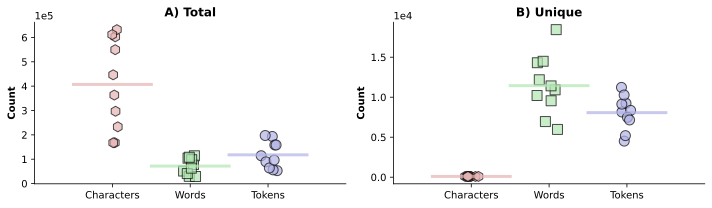

In [10]:
_, axs = plt.subplots(1, 2, figsize=(10, 3))

# marker colors and shapes
colors = [[.9, .7, .7, .7], [.7, .9, .7, .7], [.7, .7, .9, .7]]
shapes = "hso"

# loop over the three tokenizer features (0=chars, 1=words, 2=tokens)
for i in range(3):

    # individual data points (10 books, jittered around x=i)
    axs[0].plot(
        np.random.normal(
            i, 
            .06, 
            len(bookurls)
        ),
        totals[i, :],
        "k" + shapes[i],
        markerfacecolor=colors[i],
        markersize=10
    )

    # the mean (a short horizontal line at the average)
    axs[0].plot(
        [i - .5, i + .5],
        np.mean(totals[i, :]) * np.ones(2),
        color=colors[i],
        linewidth=3
    )

    # repeat for unique counts
    axs[1].plot(
        np.random.normal(
            i,
            .06,
            len(bookurls)
        ),
        uniques[i, :],
        "k" + shapes[i],
        markerfacecolor=colors[i],
        markersize=10
    )

    axs[1].plot(
        [i - .5, i + .5],
        np.mean(uniques[i, :]) * np.ones(2),
        color=colors[i],
        linewidth=3
    )

# axis adjustments
axs[0].set(
    xticks=[0, 1, 2],
    xticklabels=["Characters", "Words", "Tokens"],
    xlim=[-1, 3],
    ylabel="Count",
    title="A) Total"
)

axs[1].set(
    xticks=[0, 1, 2],
    xticklabels=["Characters", "Words", "Tokens"],
    xlim=[-1, 3],
    ylabel="Count",
    title="B) Unique"
)

axs[0].ticklabel_format(
    style="scientific",
    axis="y",
    scilimits=(0, 0)
)

axs[1].ticklabel_format(
    style="scientific",
    axis="y",
    scilimits=(0, 0)
)

plt.tight_layout()
plt.savefig("images/ch2-proj2-pt2.png")
plt.show()

**How to read this figure:** each dot is one of the 10 books.

Within each group, the marker shape tells you the measure — **hexagons = characters**, **squares = words**, **circles = tokens** — and the short **horizontal bar is the mean** across all 10 books.

Panel **A) Total** shows raw counts.

Panel **B) Unique** shows distinct counts.

*(The dots are nudged slightly left and right so they don't sit on top of each other — only their **height** carries meaning, not their horizontal position.)*

# **Part 3: Unique by total counts**

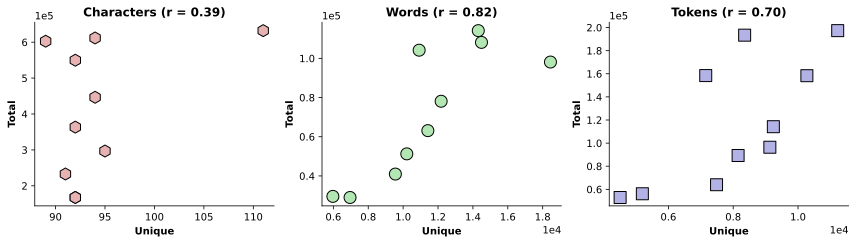

In [11]:
_, axs = plt.subplots(1, 3, figsize=(12, 3.5))

markers = ["kh", "ko", "ks"]
labels = ["Characters", "Words", "Tokens"]

for i in range(3):
    
    # pick the color for these markers
    color = [.7, .7, .7]
    color[i] = .9

    # correlation between total and unique count
    r = np.corrcoef(
        uniques[i, :],
        totals[i, :]
    )[0, 1]
    title = f"{labels[i]} (r = {r:.2f})"

    # make the plot
    axs[i].plot(
        uniques[i, :],
        totals[i, :],
        markers[i],
        markerfacecolor=color,
        markersize=12
    )
    axs[i].set(
        xlabel="Unique",
        ylabel="Total",
        title=title
    )

    # scientific notation in plot labels (except for characters)
    if i == 0:
        axs[i].ticklabel_format(
            style="scientific",
            axis="y",
            scilimits=(0, 0)
        )
    else:
        axs[i].ticklabel_format(
            style="scientific",
            axis="both",
            scilimits=(0, 0)
        )

plt.tight_layout()
plt.savefig("images/ch2-proj2-pt3.png")
plt.show()

### What `np.corrcoef` is doing

**The name:** `corrcoef` = **corr**elation **coef**ficient — the standard statistics term for a single number measuring how two things relate.

#### Total vs. unique

Take this sentence:

> the cat sat on the mat the end

- **Total** words = **8** — count every word as you walk through
- **Unique** words = **6** — `the`, `cat`, `sat`, `on`, `mat`, `end`. "the" showed up 3 times but counts **once**

Total = *how much writing there is.* Unique = *how big the vocabulary is.* A book can be enormous and repetitive (huge total, small unique), or short and full of rare words (small total, big unique).

#### The question each panel asks

**"If a book is longer, does it also use more different stuff?"**

Each dot is **one book**. For each book:

- **x** (horizontal) = its **unique** count — how many *different* things it used
- **y** (vertical) = its **total** count — how much it wrote overall

Then look at the shape:

- Dots form a **rising line** → yes, longer books use more variety. r near **+1**.
- Dots form a **flat blob** → no, length tells you nothing about variety. r near **0**.

`np.corrcoef` puts a number on which picture you're looking at, so you don't have to squint.

| r | meaning |
|---|---------|
| **+1.0** | perfect: when x goes up, y goes up, every time, proportionally |
| **+0.7** | strong positive relationship, some scatter |
| **0.0** | no linear relationship — knowing x tells you nothing about y |
| **−0.7** | strong *inverse* relationship: x up, y down |
| **−1.0** | perfect inverse |

Two notes on r: it's **scale-free** (correlating counts in the hundreds of thousands against counts near 90 works fine), and it **only sees straight lines** (a perfect U-shape gives r ≈ 0 — that's "no *linear* relationship," not "no relationship").

#### Why the `[0, 1]` on the end

`np.corrcoef` does **not** return a number — it returns a **matrix**, every input correlated against every input. With two inputs that's a 2×2:

```
            x         y
    x  [ r(x,x)   r(x,y) ]      ->  [ 1.00   0.87 ]
    y  [ r(y,x)   r(y,y) ]          [ 0.87   1.00 ]
```

The diagonal is always 1.0 (everything correlates perfectly with itself — useless), and the matrix is symmetric. The one number actually wanted sits off the diagonal, so `[0, 1]` grabs it. `[1, 0]` would be identical.

#### Why the three panels disagree

This is the point of the project. Look at the unique counts across the 10 books:

| | unique counts |
|---|---|
| **Characters** | 94, 95, 92, 92, 89, 91, 92, 111, 92, 94 |
| **Words** | 12179, 10210, 5973, 6957, 14308, 9555, 10918, 18445, 11417, 14491 |

**Characters barely move.** Every book sits near ~90 regardless of length, because English only *has* so many symbols — 26 letters in two cases, digits, punctuation. Even a 600,000-character book runs out of new characters within its first page. The supply is **capped**.

**Words move a lot** — 5,973 up to 18,445. There's no cap on vocabulary; an author can always reach for another word. So writing more genuinely does mean using more different words.

The finding: **characters run out, words don't.** The r values just measure that.

In [12]:
# which book is the outlier, and why?
import unicodedata

# derive the outlier rather than hardcoding it
i = uniques[0, :].argmax()
title = bookurls[i][1]
others = np.delete(uniques[0, :], i)

print(f"uniques[0, {i}]  ->  row 0 = characters, column {i} = book #{i} ({title})")
print(f"{'':15}= {uniques[0, i]:.0f} DISTINCT characters used in {title}")
print(f"{'':15}  other 9 books: {others.min():.0f}-{others.max():.0f} (median {np.median(others):.0f})")
print()

# pull the outlier's text and check every character in it
# direct link: https://www.gutenberg.org/cache/epub/2148/pg2148.txt
text = requests.get(baseurl + bookurls[i][0] + "/pg" + bookurls[i][0] + ".txt").text

chars = sorted(set(text))
exotic = [c for c in chars if ord(c) >= 128]

print(f"Character inventory for {title}")
print(f"  {len(chars) - len(exotic):>3}  plain ASCII   letters, digits, punctuation, whitespace")
print(f"  {len(exotic):>3}  non-ASCII     <- where the extra characters come from")
print(f"  {len(chars):>3}  total")
print()

# group the non-ASCII characters by what kind of thing they are
groups = {
    "LATIN": ["accented Latin", []],
    "GREEK": ["Greek capitals", []],
    "OTHER": ["typography & symbols", []],
}
for c in exotic:
    name = unicodedata.name(c, "")
    key = name.split()[0] if name.split()[0] in groups else "OTHER"
    groups[key][1].append(c)

notes = {
    "LATIN": "Poe quotes French and Latin constantly",
    "GREEK": "actual Greek in his essays -- note A, E, M look like Latin letters,\n         but they are different codepoints, so set() counts them separately",
    "OTHER": "em dash and smart quotes; common in most Gutenberg texts",
}

print("Non-ASCII, grouped:")
for key, (label, cs) in groups.items():
    if not cs:
        continue
    print(f"  {label} ({len(cs)}):  " + " ".join(cs))
    print(f"      -> {notes[key]}")

uniques[0, 7]  ->  row 0 = characters, column 7 = book #7 (EdgarAllenPoe)
               = 111 DISTINCT characters used in EdgarAllenPoe
                 other 9 books: 89-95 (median 92)

Character inventory for EdgarAllenPoe
   85  plain ASCII   letters, digits, punctuation, whitespace
   26  non-ASCII     <- where the extra characters come from
  111  total

Non-ASCII, grouped:
  accented Latin (13):  Æ à â ä æ ç è é ê ë ô ö œ
      -> Poe quotes French and Latin constantly
  Greek capitals (6):  Α Γ Ε Λ Μ Ξ
      -> actual Greek in his essays -- note A, E, M look like Latin letters,
         but they are different codepoints, so set() counts them separately
  typography & symbols (7):  — ‘ ’ “ ” • ™
      -> em dash and smart quotes; common in most Gutenberg texts
